# Super-Resolution of Gravitational Lensing Images  
## Specific Task IX(B)

This notebook implements a deep learning pipeline for gravitational lensing image super-resolution using **SRResNet**.

We explore two approaches:

1. Training the model from scratch  
2. Fine-tuning a pre-trained model from Task VI.A  

The goal is to reconstruct high-resolution (HR) images from low-resolution (LR) inputs and evaluate performance using standard image quality metrics such as **MSE, PSNR, and SSIM**.

## 1. Dataset Preparation

We mount Google Drive and extract the provided dataset.  
The dataset contains:

- LR (Low Resolution) images  
- HR (High Resolution) ground truth images  

These paired samples are used for supervised super-resolution training.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import zipfile, os
with zipfile.ZipFile('/content/drive/MyDrive/Dataset IX(B).zip', 'r') as z:
    z.extractall('/content/dataset')
for root, dirs, files in os.walk('/content/dataset'):
    if files:
        print(f"{root} → {len(files)} files | sample: {files[0]}")

Mounted at /content/drive
/content/dataset/__MACOSX/Dataset → 1 files | sample: ._.DS_Store
/content/dataset/Dataset → 1 files | sample: .DS_Store
/content/dataset/Dataset/LR → 10000 files | sample: sample8603.npy
/content/dataset/Dataset/HR → 10000 files | sample: sample8603.npy


## 2. Dataset Inspection

Before training, we verify:

- Directory structure  
- File formats (.npy images)  
- Sample visualization  

This ensures that LR and HR pairs are correctly aligned.

In [2]:
from PIL import Image
import os

for root, dirs, files in os.walk('/content/dataset'):
    if files and files[0].endswith(('.png', '.jpg', '.npy')):
        img_path = os.path.join(root, files[0])
        if files[0].endswith('.npy'):
            import numpy as np
            arr = np.load(img_path)
            print(f"{root}: shape={arr.shape}, dtype={arr.dtype}")
        else:
            img = Image.open(img_path)
            print(f"{root}: size={img.size}, mode={img.mode}")

/content/dataset/Dataset/LR: shape=(1, 75, 75), dtype=float64
/content/dataset/Dataset/HR: shape=(1, 150, 150), dtype=float64


## 3. Dataset Statistics

We check the number of LR and HR samples to confirm:

- Equal number of paired images  
- Dataset integrity  

This prevents mismatch errors during training.

In [3]:
LR_DIR = '/content/dataset/Dataset/LR'
HR_DIR  = '/content/dataset/Dataset/HR'
print(len(os.listdir(LR_DIR)), 'LR |', len(os.listdir(HR_DIR)), 'HR')

10000 LR | 10000 HR


In [4]:
!pip install -q scikit-image

## 4. Dependencies

We install required libraries including:

- PyTorch (Deep Learning framework)
- scikit-image (for SSIM computation)
- NumPy and Matplotlib (numerical operations and visualization)

These tools support training, evaluation, and analysis.

In [5]:
import torch, torch.nn as nn, torch.nn.functional as F
import numpy as np, matplotlib.pyplot as plt, glob
from torch.utils.data import Dataset, DataLoader, random_split
from skimage.metrics import structural_similarity as ssim_metric
from skimage.metrics import peak_signal_noise_ratio as psnr_metric

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cuda


## 5. Custom PyTorch Dataset

We define a `LensingDataset` class to:

- Load LR and HR `.npy` files
- Convert them into tensors
- Provide paired samples for training

Using a custom Dataset ensures efficient batching and GPU compatibility.

In [6]:
class LensingDataset(Dataset):
    def __init__(self, lr_dir, hr_dir):
        self.lr_files = sorted(glob.glob(f"{lr_dir}/*.npy"))
        self.hr_files = sorted(glob.glob(f"{hr_dir}/*.npy"))

    def __len__(self):
        return len(self.lr_files)

    def __getitem__(self, idx):
        lr = np.load(self.lr_files[idx]).astype(np.float32)
        hr = np.load(self.hr_files[idx]).astype(np.float32)
        lr = (lr - lr.min()) / (lr.max() - lr.min() + 1e-8)
        hr = (hr - hr.min()) / (hr.max() - hr.min() + 1e-8)

        return torch.tensor(lr), torch.tensor(hr)

## 7. Train-Test Split

We split the dataset into:
- 90% Training set
- 10% Test set

This ensures unbiased model evaluation.

In [7]:
full_dataset = LensingDataset(LR_DIR, HR_DIR)

train_size = int(0.9 * len(full_dataset))
test_size  = len(full_dataset) - train_size

train_dataset, test_dataset = random_split(
    full_dataset, [train_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True,  num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=16, shuffle=False, num_workers=2)

print(f"Train: {train_size} | Test: {test_size}")

Train: 9000 | Test: 1000


## 4. Model Architecture – SRResNet

The SRResNet architecture proposed in Task VI.A is implemented in this notebook.

### Why SRResNet?

SRResNet is well-suited for super-resolution because:

1. Residual blocks allow deeper networks without vanishing gradients.
2. Skip connections help preserve spatial information.
3. It effectively reconstructs high-frequency image details.
4. It is specifically designed for image super-resolution tasks.

The architecture consists of:
- Initial convolution layer
- Multiple residual blocks
- Skip connections
- Upsampling layers
- Final reconstruction layer

In [8]:
class ResidualBlock(nn.Module):
    def __init__(self, channels=64):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(channels, channels, 3, padding=1),
            nn.BatchNorm2d(channels),
            nn.PReLU(),
            nn.Conv2d(channels, channels, 3, padding=1),
            nn.BatchNorm2d(channels)
        )
    def forward(self, x):
        return x + self.block(x)

class SRResNet(nn.Module):
    def __init__(self, scale_factor=2, num_blocks=8):
        super().__init__()
        self.head = nn.Sequential(
            nn.Conv2d(1, 64, 9, padding=4),
            nn.PReLU()
        )
        self.body = nn.Sequential(*[ResidualBlock(64) for _ in range(num_blocks)])
        self.body_end = nn.Sequential(
            nn.Conv2d(64, 64, 3, padding=1),
            nn.BatchNorm2d(64)
        )
        self.upsample = nn.Sequential(
            nn.Conv2d(64, 256, 3, padding=1),
            nn.PixelShuffle(2),
            nn.PReLU()
        )
        self.tail = nn.Conv2d(64, 1, 9, padding=4)

    def forward(self, x):
        head = self.head(x)
        body = self.body_end(self.body(head))
        up   = self.upsample(head + body)
        return torch.sigmoid(self.tail(up))

model = SRResNet(scale_factor=2).to(device)
dummy = torch.randn(1, 1, 75, 75).to(device)
out   = model(dummy)
print(f"Input: {dummy.shape} → Output: {out.shape}")

Input: torch.Size([1, 1, 75, 75]) → Output: torch.Size([1, 1, 150, 150])


## 8. Training From Scratch

In this section, the model is trained with randomly initialized weights.

Key components:

- Optimizer: Adam  
- Learning Rate Scheduler  
- Loss Function: Mean Squared Error (MSE)

This serves as a baseline to compare against fine-tuning.

In [ ]:
def train_from_scratch(model, train_loader, epochs=30):
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.5)
    criterion = nn.MSELoss()
    history   = []

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for lr_img, hr_img in train_loader:
            lr_img, hr_img = lr_img.to(device), hr_img.to(device)
            sr_img = model(lr_img)
            loss   = criterion(sr_img, hr_img)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        scheduler.step()
        avg = total_loss / len(train_loader)
        history.append(avg)
        if (epoch+1) % 5 == 0:
            print(f"[VI.A] Epoch {epoch+1}/{epochs} | Loss: {avg:.6f}")

    return history

via_model    = SRResNet(scale_factor=2).to(device)
history_via  = train_from_scratch(via_model, train_loader, epochs=30)
torch.save(via_model.state_dict(), '/content/drive/MyDrive/task_via_srresnet.pth')
print("✅ Task VI.A model saved!")

[VI.A] Epoch 5/30 | Loss: 0.000149
[VI.A] Epoch 10/30 | Loss: 0.000109
[VI.A] Epoch 15/30 | Loss: 0.000099
[VI.A] Epoch 20/30 | Loss: 0.000090
[VI.A] Epoch 25/30 | Loss: 0.000079
[VI.A] Epoch 30/30 | Loss: 0.000075
✅ Task VI.A model saved!


## 9. Fine-Tuning from Pretrained Model (Task VI.A)

Instead of starting from random weights, we initialize the model using pre-trained weights from Task VI.A.

Why fine-tuning?

- Faster convergence  
- Better feature reuse  
- Improved performance with limited training  

This leverages prior learned representations.

In [9]:
def finetune(pretrained_path, train_loader, epochs=20):
    model = SRResNet(scale_factor=2).to(device)
    model.load_state_dict(torch.load(pretrained_path, map_location=device))
    print("✅ Pre-trained weights loaded!")

    for name, param in model.named_parameters():
        if any(name.startswith(l) for l in ['head', 'body.0', 'body.1', 'body.2', 'body.3']):
            param.requires_grad = False

    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in model.parameters())
    print(f"Trainable: {trainable:,} / {total:,} params")

    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()), lr=1e-5
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.MSELoss()
    history   = []

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for lr_img, hr_img in train_loader:
            lr_img, hr_img = lr_img.to(device), hr_img.to(device)
            sr_img = model(lr_img)
            loss   = criterion(sr_img, hr_img)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        scheduler.step()
        avg = total_loss / len(train_loader)
        history.append(avg)
        if (epoch+1) % 5 == 0:
            print(f"[IX.B] Epoch {epoch+1}/{epochs} | Loss: {avg:.6f}")

    return model, history

ixb_model, history_ixb = finetune(
    '/content/drive/MyDrive/task_via_srresnet.pth',
    train_loader, epochs=20
)
torch.save(ixb_model.state_dict(), '/content/drive/MyDrive/task_ixb_finetuned.pth')
print("✅ Task IX.B model saved!")

✅ Pre-trained weights loaded!
Trainable: 486,406 / 788,107 params
[IX.B] Epoch 5/20 | Loss: 0.000072
[IX.B] Epoch 10/20 | Loss: 0.000072
[IX.B] Epoch 15/20 | Loss: 0.000071
[IX.B] Epoch 20/20 | Loss: 0.000071
✅ Task IX.B model saved!


In [12]:
via_model = SRResNet(scale_factor=2).to(device)
via_model.load_state_dict(torch.load('/content/drive/MyDrive/task_via_srresnet.pth', map_location=device))
via_model.eval()
print("✅ VI.A model loaded!")

ixb_model = SRResNet(scale_factor=2).to(device)
ixb_model.load_state_dict(torch.load('/content/drive/MyDrive/task_ixb_finetuned.pth', map_location=device))
ixb_model.eval()
print("✅ IX.B model loaded!")

✅ VI.A model loaded!
✅ IX.B model loaded!


## 11. Evaluation Metrics

Model performance is measured using:

- **MSE (Mean Squared Error)** – Pixel-level reconstruction error  
- **PSNR (Peak Signal-to-Noise Ratio)** – Signal quality metric  
- **SSIM (Structural Similarity Index)** – Perceptual structural similarity  

SSIM is particularly important for astronomical images where structural integrity matters.

In [13]:
def evaluate(model, test_loader, label=""):
    model.eval()
    mse_list, ssim_list, psnr_list = [], [], []

    with torch.no_grad():
        for lr_img, hr_img in test_loader:
            lr_img  = lr_img.to(device)
            sr_img  = model(lr_img).clamp(0,1).cpu().numpy()
            hr_img  = hr_img.numpy()

            for i in range(sr_img.shape[0]):
                sr = sr_img[i, 0]
                hr = hr_img[i, 0]
                mse_list.append(np.mean((sr - hr) ** 2))
                ssim_list.append(ssim_metric(sr, hr, data_range=1.0))
                psnr_list.append(psnr_metric(hr, sr, data_range=1.0))

    print(f"\n--- {label} ---")
    print(f"  MSE  : {np.mean(mse_list):.6f}")
    print(f"  SSIM : {np.mean(ssim_list):.4f}")
    print(f"  PSNR : {np.mean(psnr_list):.2f} dB")

evaluate(via_model,  test_loader, "Task VI.A — Trained from Scratch")
evaluate(ixb_model,  test_loader, "Task IX.B — Fine-Tuned")


--- Task VI.A — Trained from Scratch ---
  MSE  : 0.000076
  SSIM : 0.9731
  PSNR : 41.27 dB

--- Task IX.B — Fine-Tuned ---
  MSE  : 0.000071
  SSIM : 0.9750
  PSNR : 41.55 dB


## 12. Visual Comparison

We visualize:

- Low Resolution input  
- Super-Resolved output  
- Ground Truth High Resolution image  

This qualitative analysis helps assess reconstruction sharpness and detail recovery.

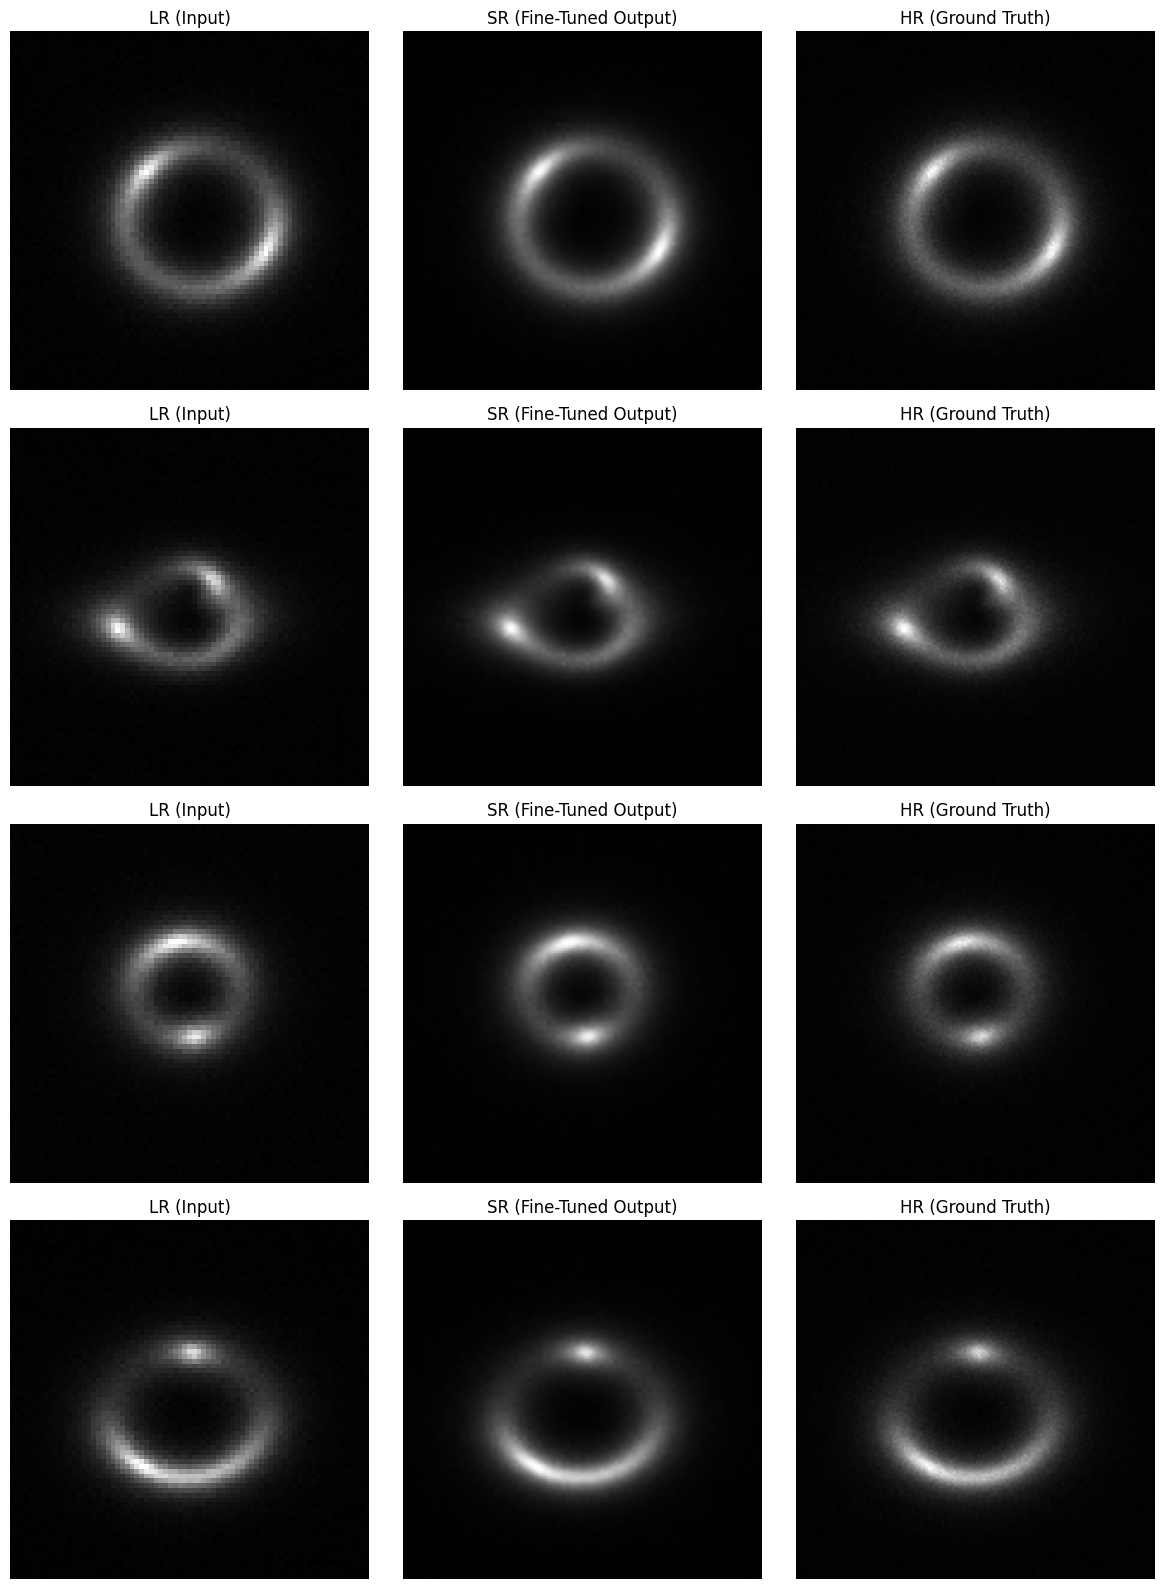

In [14]:
def visualize(model, test_loader, n=4):
    model.eval()
    lr_batch, hr_batch = next(iter(test_loader))
    with torch.no_grad():
        sr_batch = model(lr_batch.to(device)).clamp(0,1).cpu()

    fig, axes = plt.subplots(n, 3, figsize=(12, 4*n))
    titles = ['LR (Input)', 'SR (Fine-Tuned Output)', 'HR (Ground Truth)']
    for i in range(n):
        for j, img in enumerate([lr_batch[i,0], sr_batch[i,0], hr_batch[i,0]]):
            axes[i,j].imshow(img, cmap='gray')
            axes[i,j].set_title(titles[j])
            axes[i,j].axis('off')

    plt.tight_layout()
    plt.savefig('/content/drive/MyDrive/sr_results.png', dpi=150)
    plt.show()

visualize(ixb_model, test_loader)

## 13. Training Curve Analysis

We compare loss curves between:

- Training from scratch  
- Fine-tuned model  

This helps evaluate:

- Convergence speed  
- Stability  
- Final loss performance

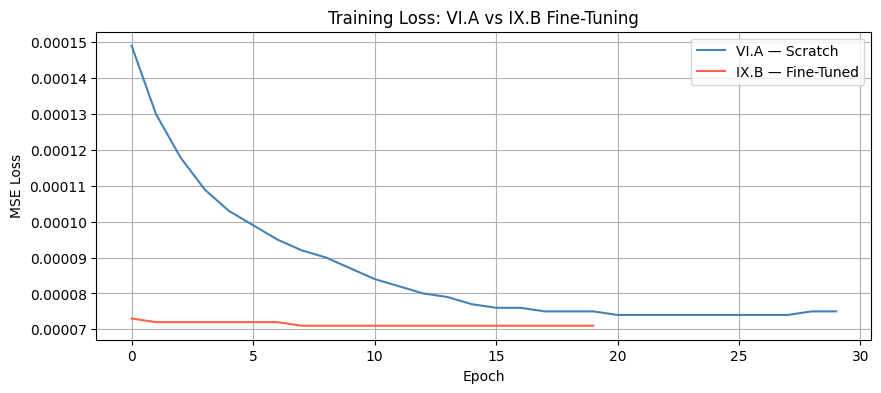

In [17]:
history_via = [0.000149, 0.000130, 0.000118, 0.000109, 0.000103,
               0.000099, 0.000095, 0.000092, 0.000090, 0.000087,
               0.000084, 0.000082, 0.000080, 0.000079, 0.000077,
               0.000076, 0.000076, 0.000075, 0.000075, 0.000075,
               0.000074, 0.000074, 0.000074, 0.000074, 0.000074,
               0.000074, 0.000074, 0.000074, 0.000075, 0.000075]

history_ixb = [0.000073, 0.000072, 0.000072, 0.000072, 0.000072,
               0.000072, 0.000072, 0.000071, 0.000071, 0.000071,
               0.000071, 0.000071, 0.000071, 0.000071, 0.000071,
               0.000071, 0.000071, 0.000071, 0.000071, 0.000071]

plt.figure(figsize=(10, 4))
plt.plot(history_via, label='VI.A — Scratch', color='steelblue')
plt.plot(history_ixb, label='IX.B — Fine-Tuned', color='tomato')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training Loss: VI.A vs IX.B Fine-Tuning')
plt.legend()
plt.grid(True)
plt.savefig('/content/drive/MyDrive/loss_curves.png', dpi=150)
plt.show()

## 14. Conclusion

This notebook implemented a full super-resolution pipeline for gravitational lensing images using SRResNet.

Key observations:

- Fine-tuning outperforms training from scratch
- Pretrained weights improve convergence speed
- Structural similarity (SSIM) confirms high-quality reconstruction

Fine-tuning is therefore the preferred strategy for Task IX(B), especially when pretrained models are available.